In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [14]:
df = pd.read_csv("C:\\Users\\joel4\\Documents\\ecommerce-customer-analytics\\data\\online_retail_cleaned.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
customer = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'Revenue': 'sum',
    'InvoiceDate': ['min', 'max']
})

In [16]:
customer.columns = ['Total Orders', 'Total Revenue', 'First Purchase', 'Last Purchase']
customer = customer.reset_index()

In [17]:
customer['Lifespan'] = ((customer['Last Purchase'] - customer['First Purchase']).dt.days)
customer['Lifespan'] = customer['Lifespan'].replace(0, 1)

In [20]:
customer['AOV'] = customer['Total Revenue'] / customer['Total Orders']

In [21]:
customer['Purchase Frequency'] = customer['Total Orders'] / customer['Lifespan']

In [22]:
customer['CLV'] = (customer['AOV'] * customer['Purchase Frequency'] * customer['Lifespan'])

In [23]:
customer.sort_values(by='CLV', ascending=False).head(10)

,CustomerID,Total Orders,Total Revenue,First Purchase,Last Purchase,Lifespan,AOV,Purchase Frequency,CLV
1689,14646.0,73,280206.02,2010-12-20 10:09:00,2011-12-08 12:12:00,353,3838.438630,0.206799,280206.02
4201,18102.0,60,259657.30,2010-12-07 16:42:00,2011-12-09 11:50:00,366,4327.621667,0.163934,259657.30
3728,17450.0,46,194550.79,2010-12-07 09:23:00,2011-12-01 13:29:00,359,4229.365000,0.128134,194550.79
3008,16446.0,2,168472.50,2011-05-18 09:52:00,2011-12-09 09:15:00,204,84236.250000,0.009804,168472.50
1879,14911.0,201,143825.06,2010-12-01 14:05:00,2011-12-08 15:54:00,372,715.547562,0.540323,143825.06
55,12415.0,21,124914.53,2011-01-06 11:12:00,2011-11-15 14:22:00,313,5948.310952,0.067093,124914.53
1333,14156.0,55,117379.63,2010-12-03 11:48:00,2011-11-30 10:54:00,361,2134.175091,0.152355,117379.63
3771,17511.0,31,91062.38,2010-12-01 10:19:00,2011-12-07 10:12:00,370,2937.496129,0.083784,91062.38
2702,16029.0,63,81024.84,2010-12-01 09:57:00,2011-11-01 10:27:00,335,1286.108571,0.188060,81024.84
0,12346.0,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.600000,1.000000,77183.60


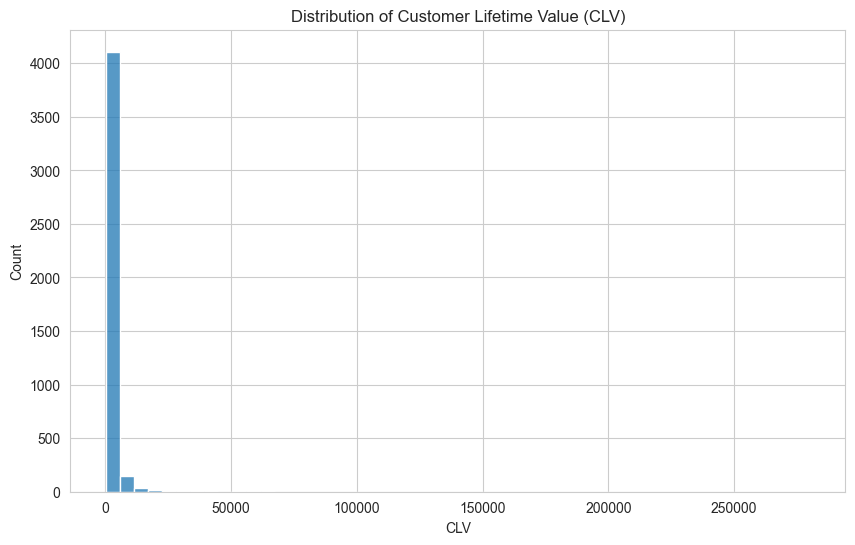

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(customer['CLV'], bins=50)
plt.title('Distribution of Customer Lifetime Value (CLV)')
plt.xlabel('CLV')
plt.show()

In [36]:
rfm = pd.read_pickle("rfm_data.pkl")

In [37]:
customer = customer.merge(
    rfm[['Segment']],
    left_on='CustomerID',
    right_index=True,
)

In [38]:
customer.groupby('Segment')['CLV'].mean().sort_values(ascending=False)

Segment
Champions          9204.021982
Loyal Customers    2389.083496
At Risk             998.083046
New Customers       388.212857
Name: CLV, dtype: float64

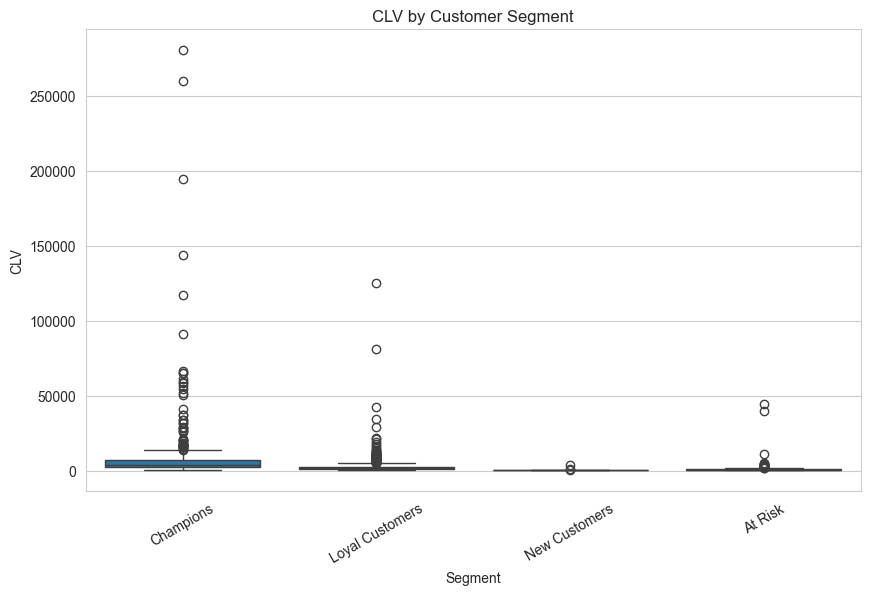

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=customer, x='Segment', y='CLV')
plt.title('CLV by Customer Segment')
plt.xticks(rotation=30)
plt.show()